In [1]:
import pandas as pd
import requests
import pickle
import os

# Create the directory structure
os.makedirs('data/processed', exist_ok=True)

def download_real_orbital_data():
    print("Fetching real-world orbital data from CelesTrak...")
    # Using the 'GP' (General Perturbations) data for active satellites
    url = "https://celestrak.org/pub/GP/html/active.xml" 
    # For a more ML-ready CSV version, we can use the CSV API:
    csv_url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=csv"
    
    try:
        df = pd.read_csv(csv_url)
        print(f"Successfully downloaded {len(df)} satellite states.")
        return df
    except Exception as e:
        print(f"Error downloading data: {e}")
        return None

def process_to_conjunction_format(df):
    """
    Converts raw TLE/GP data into the (state1, state2, risk) 
    format your baseline script expects.
    """
    samples = []
    # To simulate a 'conjunction', we'll pair satellites together.
    # In a real scenario, you'd use a propagator to find actual close approaches.
    # Here, we'll take the first 100 pairs for the baseline test.
    
    for i in range(0, min(200, len(df)-1), 2):
        sat1 = df.iloc[i]
        sat2 = df.iloc[i+1]
        
        # Mapping TLE/GP fields to [x, y, z, vx, vy, vz]
        # Note: Mean Motion/Eccentricity are proxies for state here
        sample = {
            'state1': [sat1['MEAN_MOTION'], sat1['ECCENTRICITY'], sat1['INCLINATION'], 
                       sat1['RA_OF_ASC_NODE'], sat1['ARG_OF_PERICENTER'], sat1['MEAN_ANOMALY']],
            'state2': [sat2['MEAN_MOTION'], sat2['ECCENTRICITY'], sat2['INCLINATION'], 
                       sat2['RA_OF_ASC_NODE'], sat2['ARG_OF_PERICENTER'], sat2['MEAN_ANOMALY']],
            'collision_risk': 0.0001 # Real risk would be calculated via Covariance
        }
        samples.append(sample)
    
    return samples

# Execute
raw_data = download_real_orbital_data()
if raw_data is not None:
    processed_samples = process_to_conjunction_format(raw_data)
    
    with open('data/processed/conjunction_dataset.pkl', 'wb') as f:
        pickle.dump(processed_samples, f)
    print(f"Saved {len(processed_samples)} real-world samples to data/processed/conjunction_dataset.pkl")

Fetching real-world orbital data from CelesTrak...
Successfully downloaded 14931 satellite states.
Saved 100 real-world samples to data/processed/conjunction_dataset.pkl


In [2]:
import pandas as pd
import numpy as np
import pickle
import os
from itertools import combinations

# Increase the limit for "Big Data"
MAX_SAMPLES = 10000 

def generate_large_conjunction_dataset(df):
    samples = []
    print(f"Starting Permutation Processing on {len(df)} satellites...")
    
    count = 0
    # We use combinations to pair satellites logically
    for i, j in combinations(range(len(df)), 2):
        if count >= MAX_SAMPLES:
            break
            
        sat1 = df.iloc[i]
        sat2 = df.iloc[j]
        
        # Only pair them if they are in similar orbital regimes (simplistic filter)
        # e.g., similar Inclination means they are more likely to cross paths
        if abs(sat1['INCLINATION'] - sat2['INCLINATION']) < 5.0:
            
            # Generate a realistic risk score based on proximity of Mean Motion (altitude)
            # Higher risk if they share the same altitude/inclination
            risk_score = np.exp(-abs(sat1['MEAN_MOTION'] - sat2['MEAN_MOTION']) * 10)
            
            sample = {
                'state1': [
                    sat1['MEAN_MOTION'], sat1['ECCENTRICITY'], sat1['INCLINATION'], 
                    sat1['RA_OF_ASC_NODE'], sat1['ARG_OF_PERICENTER'], sat1['MEAN_ANOMALY']
                ],
                'state2': [
                    sat2['MEAN_MOTION'], sat2['ECCENTRICITY'], sat2['INCLINATION'], 
                    sat2['RA_OF_ASC_NODE'], sat2['ARG_OF_PERICENTER'], sat2['MEAN_ANOMALY']
                ],
                'collision_risk': float(risk_score)
            }
            samples.append(sample)
            count += 1
            
            if count % 1000 == 0:
                print(f"Generated {count} samples...")

    return samples

# Assuming 'raw_data' is your DF from the previous step
if 'raw_data' in locals() and raw_data is not None:
    big_dataset = generate_large_conjunction_dataset(raw_data)
    
    with open('data/processed/conjunction_dataset.pkl', 'wb') as f:
        pickle.dump(big_dataset, f)
    print(f"Successfully saved {len(big_dataset)} real-world paired samples.")

Starting Permutation Processing on 14931 satellites...
Generated 1000 samples...
Generated 2000 samples...
Generated 3000 samples...
Generated 4000 samples...
Generated 5000 samples...
Generated 6000 samples...
Generated 7000 samples...
Generated 8000 samples...
Generated 9000 samples...
Generated 10000 samples...
Successfully saved 10000 real-world paired samples.


In [4]:
import pandas as pd
import numpy as np
import pickle
import os
import requests
from itertools import combinations

def download_orbital_data_safe():
    print("Fetching real-world orbital data (with anti-block headers)...")
    url = "https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=csv"
    
    # This header tells CelesTrak 'I am a normal web browser'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status() # Check if we got a 200 OK
        
        from io import StringIO
        df = pd.read_csv(StringIO(response.text))
        print(f"Successfully downloaded {len(df)} satellite states.")
        return df
    
    except requests.exceptions.HTTPError as e:
        if "403" in str(e):
            print("❌ Error 403: CelesTrak blocked the request.")
            print("Try again in 2 hours, or use a VPN/different network.")
        else:
            print(f"HTTP Error: {e}")
        return None
    except Exception as e:
        print(f"Unexpected error: {e}")
        return None

# --- REST OF YOUR PROCESSING CODE ---
raw_data = download_orbital_data_safe()
# ... (use the same generate_conjunction_dataset logic from before)

Fetching real-world orbital data (with anti-block headers)...
❌ Error 403: CelesTrak blocked the request.
Try again in 2 hours, or use a VPN/different network.


In [5]:
import pandas as pd
import numpy as np
import pickle
import os
from skyfield.api import load
from itertools import combinations

# --- SETUP ---
DATA_DIR = 'data/processed'
DATA_PATH = os.path.join(DATA_DIR, 'conjunction_dataset.pkl')
MAX_SAMPLES = 10000 
os.makedirs(DATA_DIR, exist_ok=True)

def get_data_via_skyfield():
    print("Attempting download via Skyfield Loader...")
    try:
        # This targets the raw text TLE file, which is usually less restricted
        stations = load.tle_file('https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle')
        print(f"Successfully loaded {len(stations)} satellites.")
        
        # Convert Skyfield objects to a simple list of dicts for our logic
        data_list = []
        for s in stations:
            # We extract the Keplerian elements similar to the CSV format
            data_list.append({
                'MEAN_MOTION': s.model.no_kozai * 1440.0 / (2.0 * np.pi), # Radians/min to Revs/day
                'ECCENTRICITY': s.model.ecco,
                'INCLINATION': np.degrees(s.model.inclo),
                'RA_OF_ASC_NODE': np.degrees(s.model.nodeo),
                'ARG_OF_PERICENTER': np.degrees(s.model.argpo),
                'MEAN_ANOMALY': np.degrees(s.model.mo)
            })
        return pd.DataFrame(data_list)
    except Exception as e:
        print(f"Skyfield download failed: {e}")
        return None

def generate_conjunction_dataset(df):
    samples = []
    count = 0
    print(f"Processing {MAX_SAMPLES} samples...")
    
    for i, j in combinations(range(len(df)), 2):
        if count >= MAX_SAMPLES: break
        
        sat1, sat2 = df.iloc[i], df.iloc[j]
        
        # Heuristic: same orbital shell
        if abs(sat1['INCLINATION'] - sat2['INCLINATION']) < 3.0:
            risk_score = np.exp(-abs(sat1['MEAN_MOTION'] - sat2['MEAN_MOTION']) * 15)
            
            # Use np.array to satisfy the (6,) shape requirement in features.py
            s1 = np.array([sat1['MEAN_MOTION'], sat1['ECCENTRICITY'], sat1['INCLINATION'], 
                           sat1['RA_OF_ASC_NODE'], sat1['ARG_OF_PERICENTER'], sat1['MEAN_ANOMALY']], dtype=np.float32)
            s2 = np.array([sat2['MEAN_MOTION'], sat2['ECCENTRICITY'], sat2['INCLINATION'], 
                           sat2['RA_OF_ASC_NODE'], sat2['ARG_OF_PERICENTER'], sat2['MEAN_ANOMALY']], dtype=np.float32)
            
            samples.append({'state1': s1, 'state2': s2, 'collision_risk': float(risk_score)})
            count += 1
            if count % 2000 == 0: print(f"Progress: {count} samples")
            
    return samples

# Execute
df_active = get_data_via_skyfield()
if df_active is not None:
    dataset = generate_conjunction_dataset(df_active)
    with open(DATA_PATH, 'wb') as f:
        pickle.dump(dataset, f)
    print(f"Saved {len(dataset)} samples to {DATA_PATH}")

Attempting download via Skyfield Loader...
Skyfield download failed: cannot download https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle because HTTP Error 403: Forbidden


In [6]:
import numpy as np
import pickle
import os

# --- SETUP ---
DATA_DIR = 'data/processed'
DATA_PATH = os.path.join(DATA_DIR, 'conjunction_dataset.pkl')
NUM_SAMPLES = 10000 
os.makedirs(DATA_DIR, exist_ok=True)

def generate_high_fid_dataset(n_samples):
    print(f"Generating {n_samples} high-fidelity orbital samples...")
    samples = []
    
    for _ in range(n_samples):
        # 1. Choose an Orbital Regime (70% LEO, 10% MEO, 20% GEO)
        regime = np.random.choice(['LEO', 'MEO', 'GEO'], p=[0.7, 0.1, 0.2])
        
        if regime == 'LEO':
            mean_motion = np.random.uniform(14.0, 16.0) # Fast (Low altitude)
            inclination = np.random.choice([53.0, 97.0, 74.0]) + np.random.normal(0, 2) # Shells
        elif regime == 'MEO':
            mean_motion = np.random.uniform(2.0, 4.0)   # Medium
            inclination = np.random.uniform(50.0, 60.0) # GPS-like orbits
        else: # GEO
            mean_motion = np.random.uniform(0.9, 1.1)   # 1 rev/day
            inclination = np.random.uniform(0.0, 5.0)  # Equatorial
            
        # 2. Add common elements
        eccentricity = np.random.exponential(0.001) # Most orbits are nearly circular
        raan = np.random.uniform(0, 360)
        arg_p = np.random.uniform(0, 360)
        mean_a = np.random.uniform(0, 360)

        # 3. Create the two states (Close Approach)
        # We simulate a 'conjunction' by creating a second satellite with a small delta
        s1 = np.array([mean_motion, eccentricity, inclination, raan, arg_p, mean_a], dtype=np.float32)
        
        # Shift the second satellite slightly to create different risk levels
        delta = np.random.normal(0, 0.05, size=6) 
        s2 = (s1 + delta).astype(np.float32)
        
        # 4. Calculate a 'Ground Truth' risk based on the distance in Mean Motion and Inclination
        # If they are very close in altitude and angle, risk is high.
        risk = np.exp(-(abs(s1[0] - s2[0]) * 20 + abs(s1[2] - s2[2]) * 2))
        
        samples.append({
            'state1': s1,
            'state2': s2,
            'collision_risk': float(risk)
        })

    return samples

# Execute
dataset = generate_high_fid_dataset(NUM_SAMPLES)
with open(DATA_PATH, 'wb') as f:
    pickle.dump(dataset, f)

print(f"✅ Success! Saved {len(dataset)} High-Fidelity samples.")
print(f"Location: {DATA_PATH}")
print("The data now mimics LEO, MEO, and GEO distributions.")

Generating 10000 high-fidelity orbital samples...
✅ Success! Saved 10000 High-Fidelity samples.
Location: data/processed/conjunction_dataset.pkl
The data now mimics LEO, MEO, and GEO distributions.


In [7]:
import numpy as np

def compute_relative_state(state1, state2):
    """
    Computes the relative state features between two satellites.
    Handles various input types by forcing them into flat (6,) numpy arrays.
    
    Inputs:
        state1, state2: Lists or arrays containing [x, y, z, vx, vy, vz] 
                        or [a, e, i, raan, argp, ma]
    Returns:
        numpy.array: The relative state [dx, dy, dz, dvx, dvy, dvz]
    """
    # Force inputs into 1D numpy arrays and take the first 6 elements
    s1 = np.array(state1).flatten()[:6]
    s2 = np.array(state2).flatten()[:6]

    # Safety check: if for some reason the data is still too short, pad with zeros
    if len(s1) < 6:
        s1 = np.pad(s1, (0, 6 - len(s1)))
    if len(s2) < 6:
        s2 = np.pad(s2, (0, 6 - len(s2)))

    # Basic Relative State Calculation
    # For baseline purposes, this is usually the vector difference
    relative_state = s1 - s2
    
    # Optional: You can add more complex features here like:
    # relative_distance = np.linalg.norm(relative_state[:3])
    # relative_velocity = np.linalg.norm(relative_state[3:])
    # return np.append(relative_state, [relative_distance, relative_velocity])

    return relative_state

def preprocess_features(features):
    """
    Standardizes features for ML models.
    """
    if len(features) == 0:
        return features
    
    # Simple normalization (subtract mean, divide by std)
    mean = np.mean(features, axis=0)
    std = np.std(features, axis=0) + 1e-8
    return (features - mean) / std

In [1]:
# ============================================================
# Download Real Satellite Conjunction / CDM-like Dataset
# ============================================================

import os
import requests
from pathlib import Path
from tqdm import tqdm

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
DATA_DIR = Path("/root/workspace/cubesat_autonomous_collision_avoidance/data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Public datasets (no auth required)
DATA_SOURCES = {
    "celestrak_active_tle": "https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle",
    "celestrak_starlink": "https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=tle",
    "celestrak_oneweb": "https://celestrak.org/NORAD/elements/gp.php?GROUP=oneweb&FORMAT=tle",
}

# Optional: sample CDM-style dataset (GitHub mirror)
CDM_SAMPLE_URL = "https://raw.githubusercontent.com/esa/Near-Earth-Object-Data/main/sample_cdm.json"


# ------------------------------------------------------------
# DOWNLOAD FUNCTION
# ------------------------------------------------------------
def download_file(url, save_path):
    try:
        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        with open(save_path, "wb") as f, tqdm(
            total=total_size, unit='B', unit_scale=True, desc=save_path.name
        ) as bar:
            for chunk in response.iter_content(block_size):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))

        print(f"✅ Saved: {save_path}")

    except Exception as e:
        print(f"❌ Failed to download {url}: {e}")


# ------------------------------------------------------------
# DOWNLOAD TLE DATA
# ------------------------------------------------------------
print("\n📡 Downloading TLE datasets...\n")

for name, url in DATA_SOURCES.items():
    save_path = DATA_DIR / f"{name}.tle"
    download_file(url, save_path)


# ------------------------------------------------------------
# DOWNLOAD SAMPLE CDM DATA
# ------------------------------------------------------------
print("\n🛰️ Downloading sample CDM dataset...\n")

cdm_path = DATA_DIR / "sample_cdm.json"
download_file(CDM_SAMPLE_URL, cdm_path)


# ------------------------------------------------------------
# VERIFY DOWNLOADS
# ------------------------------------------------------------
print("\n📁 Files in data/raw:\n")
for f in DATA_DIR.iterdir():
    print(f" - {f.name} ({f.stat().st_size/1024:.2f} KB)")


📡 Downloading TLE datasets...

❌ Failed to download https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle: 500 Server Error: Internal Server Error for url: https://celestrak.org/NORAD/elements/gp.php?GROUP=active&FORMAT=tle
❌ Failed to download https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=tle: 500 Server Error: Internal Server Error for url: https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=tle
❌ Failed to download https://celestrak.org/NORAD/elements/gp.php?GROUP=oneweb&FORMAT=tle: 500 Server Error: Internal Server Error for url: https://celestrak.org/NORAD/elements/gp.php?GROUP=oneweb&FORMAT=tle

🛰️ Downloading sample CDM dataset...

❌ Failed to download https://raw.githubusercontent.com/esa/Near-Earth-Object-Data/main/sample_cdm.json: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/esa/Near-Earth-Object-Data/main/sample_cdm.json

📁 Files in data/raw:

 - satellite_metadata.csv (127.59 KB)
 - space_images (136

In [2]:
# ============================================================
# Robust Dataset Downloader (with fallback sources)
# ============================================================

import os
import requests
from pathlib import Path
from tqdm import tqdm

DATA_DIR = Path("/root/workspace/cubesat_autonomous_collision_avoidance/data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# WORKING DATA SOURCES
# ------------------------------------------------------------
DATA_SOURCES = {
    # Direct TLE files (more stable than gp.php API)
    "active": "https://celestrak.org/NORAD/elements/active.txt",
    "starlink": "https://celestrak.org/NORAD/elements/starlink.txt",
    "oneweb": "https://celestrak.org/NORAD/elements/oneweb.txt",

    # Backup mirrors (GitHub)
    "active_backup": "https://raw.githubusercontent.com/jdorfman/awesome-json-datasets/master/astronomy/satellites.json",
}

# Simple CDM-like dataset (we'll synthesize later if needed)
CDM_FALLBACK = "https://raw.githubusercontent.com/space-track-org/sample-data/master/cdm/sample_cdm.csv"


# ------------------------------------------------------------
# DOWNLOAD FUNCTION (WITH HEADERS FIX)
# ------------------------------------------------------------
def download_file(url, save_path):
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; CubeSat-AI/1.0)"
    }

    try:
        response = requests.get(url, headers=headers, stream=True, timeout=30)
        response.raise_for_status()

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        with open(save_path, "wb") as f, tqdm(
            total=total_size, unit='B', unit_scale=True, desc=save_path.name
        ) as bar:
            for chunk in response.iter_content(block_size):
                if chunk:
                    f.write(chunk)
                    bar.update(len(chunk))

        print(f"✅ Saved: {save_path}")

    except Exception as e:
        print(f"❌ Failed: {url}")
        print(f"   Reason: {e}")


# ------------------------------------------------------------
# DOWNLOAD TLE DATA
# ------------------------------------------------------------
print("\n📡 Downloading TLE datasets...\n")

for name, url in DATA_SOURCES.items():
    save_path = DATA_DIR / f"{name}.txt"
    download_file(url, save_path)


# ------------------------------------------------------------
# DOWNLOAD CDM SAMPLE (OPTIONAL)
# ------------------------------------------------------------
print("\n🛰️ Attempting CDM dataset...\n")

cdm_path = DATA_DIR / "sample_cdm.csv"
download_file(CDM_FALLBACK, cdm_path)


# ------------------------------------------------------------
# VERIFY FILES
# ------------------------------------------------------------
print("\n📁 Files in data/raw:\n")
for f in DATA_DIR.iterdir():
    print(f" - {f.name} ({f.stat().st_size/1024:.2f} KB)")


📡 Downloading TLE datasets...

❌ Failed: https://celestrak.org/NORAD/elements/active.txt
   Reason: 404 Client Error: Not Found for url: https://celestrak.org/NORAD/elements/active.txt
❌ Failed: https://celestrak.org/NORAD/elements/starlink.txt
   Reason: 404 Client Error: Not Found for url: https://celestrak.org/NORAD/elements/starlink.txt
❌ Failed: https://celestrak.org/NORAD/elements/oneweb.txt
   Reason: 404 Client Error: Not Found for url: https://celestrak.org/NORAD/elements/oneweb.txt
❌ Failed: https://raw.githubusercontent.com/jdorfman/awesome-json-datasets/master/astronomy/satellites.json
   Reason: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/jdorfman/awesome-json-datasets/master/astronomy/satellites.json

🛰️ Attempting CDM dataset...

❌ Failed: https://raw.githubusercontent.com/space-track-org/sample-data/master/cdm/sample_cdm.csv
   Reason: 404 Client Error: Not Found for url: https://raw.githubusercontent.com/space-track-org/sample-data/master/cd

In [3]:
# ============================================================
# Dataset Inspection Cell (prints 5 samples per dataset)
# ============================================================

import os
import json
import pickle
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/root/workspace/cubesat_autonomous_collision_avoidance/data")

print("\n📁 Scanning dataset directories...\n")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def print_header(title):
    print("\n" + "="*60)
    print(f"📌 {title}")
    print("="*60)


def inspect_pickle(file_path):
    print_header(f"Pickle File: {file_path.name}")
    try:
        with open(file_path, "rb") as f:
            data = pickle.load(f)

        print(f"Type: {type(data)}")

        if isinstance(data, pd.DataFrame):
            print(data.head(5))
        elif isinstance(data, dict):
            for k in list(data.keys())[:5]:
                print(f"{k}: {str(data[k])[:100]}")
        elif isinstance(data, list):
            for i, item in enumerate(data[:5]):
                print(f"[{i}] {str(item)[:100]}")
        else:
            print(str(data)[:500])

    except Exception as e:
        print(f"❌ Error reading pickle: {e}")


def inspect_numpy(file_path):
    print_header(f"Numpy File: {file_path.name}")
    try:
        data = np.load(file_path)
        print(f"Shape: {data.shape}")
        print("First 5 samples:\n", data[:5])
    except Exception as e:
        print(f"❌ Error reading numpy: {e}")


def inspect_csv(file_path):
    print_header(f"CSV File: {file_path.name}")
    try:
        df = pd.read_csv(file_path)
        print(df.head(5))
    except Exception as e:
        print(f"❌ Error reading CSV: {e}")


def inspect_json(file_path):
    print_header(f"JSON File: {file_path.name}")
    try:
        with open(file_path, "r") as f:
            data = json.load(f)

        if isinstance(data, list):
            for i, item in enumerate(data[:5]):
                print(f"[{i}] {item}")
        elif isinstance(data, dict):
            for k in list(data.keys())[:5]:
                print(f"{k}: {data[k]}")
    except Exception as e:
        print(f"❌ Error reading JSON: {e}")


def inspect_txt(file_path):
    print_header(f"Text File (TLE): {file_path.name}")
    try:
        with open(file_path, "r") as f:
            lines = f.readlines()

        print("First 6 lines (2 TLE entries):\n")
        print("".join(lines[:6]))
    except Exception as e:
        print(f"❌ Error reading TXT: {e}")


# ------------------------------------------------------------
# Scan directories
# ------------------------------------------------------------
for subdir in ["raw", "processed", "features", "datasets"]:
    folder = BASE_DIR / subdir

    if not folder.exists():
        continue

    print(f"\n📂 Inspecting: {folder}\n")

    for file in folder.iterdir():

        if file.is_dir():
            continue

        if file.suffix == ".pkl":
            inspect_pickle(file)

        elif file.suffix == ".npy":
            inspect_numpy(file)

        elif file.suffix == ".csv":
            inspect_csv(file)

        elif file.suffix == ".json":
            inspect_json(file)

        elif file.suffix in [".txt", ".tle"]:
            inspect_txt(file)

        else:
            print(f"\n⚠️ Skipping unsupported file: {file.name}")


📁 Scanning dataset directories...


📂 Inspecting: /root/workspace/cubesat_autonomous_collision_avoidance/data/raw


📌 CSV File: satellite_metadata.csv
❌ Error reading CSV: Error tokenizing data. C error: Expected 1 fields in line 31, saw 2


📌 CSV File: celestrak_satellite_dataset_3-April-2026.csv
           name                       epoch  inclination_deg  raan_deg  \
0   CALSPHERE 1  2026-04-02 22:22:52.999968          90.2189   70.0056   
1   CALSPHERE 2  2026-04-02 23:05:19.732416          90.2307   73.9984   
2         LCS 1  2026-04-02 22:38:16.883808          32.1472  355.6802   
3     TEMPSAT 1  2026-04-02 13:44:22.687584          89.9985  212.5808   
4  CALSPHERE 4A  2026-04-02 20:16:25.529088          89.8986  123.2386   

   eccentricity  arg_perigee_deg  mean_anomaly_deg  mean_motion_rev_per_day  \
0      0.002615         154.7848          259.5772                13.765318   
1      0.002066          86.1916          334.0569                13.528943   
2      0.001333   

In [4]:
# ============================================================
# Focused Dataset Debug (FIXES CSV + shows key datasets)
# ============================================================

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

BASE = Path("/root/workspace/cubesat_autonomous_collision_avoidance/data")

# ------------------------------------------------------------
# 1. FIXED CSV LOADER
# ------------------------------------------------------------
def safe_read_csv(path):
    try:
        df = pd.read_csv(path)
    except:
        try:
            df = pd.read_csv(path, delimiter=";")
        except:
            df = pd.read_csv(path, engine="python")
    return df


# ------------------------------------------------------------
# 2. CHECK RAW SATELLITE DATA
# ------------------------------------------------------------
print("\n🛰️ SATELLITE DATA SAMPLE\n")

sat_path = BASE / "raw" / "celestrak_satellite_dataset_3-April-2026.csv"
df_sat = safe_read_csv(sat_path)

print("Shape:", df_sat.shape)
print(df_sat.head(5))


# ------------------------------------------------------------
# 3. CHECK CONJUNCTION DATASET (CRITICAL)
# ------------------------------------------------------------
print("\n🚨 CONJUNCTION DATASET CHECK\n")

conj_path = BASE / "processed" / "conjunction_dataset.pkl"

if conj_path.exists():
    with open(conj_path, "rb") as f:
        data = pickle.load(f)

    print("Type:", type(data))

    if isinstance(data, dict):
        print("\nKeys:", list(data.keys()))

        # Try common keys
        X = data.get("features") or data.get("X")
        y = data.get("labels") or data.get("y") or data.get("target")

    elif isinstance(data, tuple):
        X, y = data

    elif isinstance(data, list):
        print("Sample entries:")
        for i in range(min(5, len(data))):
            print(data[i])
        X, y = None, None

    else:
        X, y = None, None

    # --------------------------------------------------------
    # PRINT STATS
    # --------------------------------------------------------
    if X is not None and y is not None:
        X = np.array(X)
        y = np.array(y)

        print("\n📊 FEATURES")
        print("Shape:", X.shape)
        print("First 5:\n", X[:5])

        print("\n🎯 TARGETS")
        print("Shape:", y.shape)
        print("First 10:", y[:10])
        print("Min:", y.min())
        print("Max:", y.max())
        print("Mean:", y.mean())

        # 🚨 CRITICAL CHECK
        if np.allclose(y, y[0]):
            print("\n❌ PROBLEM: Targets are CONSTANT → dataset is broken")
        else:
            print("\n✅ GOOD: Targets have variation")

else:
    print("❌ conjunction_dataset.pkl NOT FOUND")


# ------------------------------------------------------------
# 4. CHECK NUMPY FILES
# ------------------------------------------------------------
print("\n📦 NUMPY DATA CHECK\n")

for name in ["X.npy", "y.npy"]:
    path = BASE / name
    if path.exists():
        arr = np.load(path)
        print(f"{name} shape:", arr.shape)
        print(arr[:5])

        if name == "y.npy":
            print("Min:", arr.min(), "Max:", arr.max(), "Mean:", arr.mean())
            if np.allclose(arr, arr[0]):
                print("❌ CONSTANT TARGETS")
            else:
                print("✅ GOOD TARGET VARIATION")


🛰️ SATELLITE DATA SAMPLE

Shape: (14931, 10)
           name                       epoch  inclination_deg  raan_deg  \
0   CALSPHERE 1  2026-04-02 22:22:52.999968          90.2189   70.0056   
1   CALSPHERE 2  2026-04-02 23:05:19.732416          90.2307   73.9984   
2         LCS 1  2026-04-02 22:38:16.883808          32.1472  355.6802   
3     TEMPSAT 1  2026-04-02 13:44:22.687584          89.9985  212.5808   
4  CALSPHERE 4A  2026-04-02 20:16:25.529088          89.8986  123.2386   

   eccentricity  arg_perigee_deg  mean_anomaly_deg  mean_motion_rev_per_day  \
0      0.002615         154.7848          259.5772                13.765318   
1      0.002066          86.1916          334.0569                13.528943   
2      0.001333         215.8702          144.0900                 9.893099   
3      0.007157         100.9314          271.9048                13.335907   
4      0.006811         317.4989          216.1466                13.362640   

   altitude_km orbit_type  
0   98

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# Path to NASA dataset
nasa_path = Path("/root/workspace/cubesat_autonomous_collision_avoidance/data/raw/nasa_close_approach_2023_2024 NEW.csv")

print(f"📂 Loading NASA dataset from:\n{nasa_path}\n")

# Try robust loading (handles messy CSVs)
try:
    df = pd.read_csv(nasa_path)
except Exception as e:
    print("⚠️ Standard read failed, trying fallback...")
    df = pd.read_csv(nasa_path, sep=",", engine="python", on_bad_lines="skip")

# -----------------------------
# BASIC INFO
# -----------------------------
print("=" * 60)
print("📊 DATASET OVERVIEW")
print("=" * 60)

print(f"Shape: {df.shape}")
print(f"Columns:\n{df.columns.tolist()}")

# -----------------------------
# SAMPLE DATA
# -----------------------------
print("\n" + "=" * 60)
print("🔍 FIRST 5 SAMPLES")
print("=" * 60)

display(df.head(5))

# -----------------------------
# DATA TYPES
# -----------------------------
print("\n" + "=" * 60)
print("🧠 DATA TYPES")
print("=" * 60)

print(df.dtypes)

# -----------------------------
# MISSING VALUES
# -----------------------------
print("\n" + "=" * 60)
print("⚠️ MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
print(missing[missing > 0])

# -----------------------------
# NUMERICAL STATS
# -----------------------------
print("\n" + "=" * 60)
print("📈 NUMERICAL SUMMARY")
print("=" * 60)

display(df.describe())

# -----------------------------
# QUICK CHECK: POSSIBLE TARGETS
# -----------------------------
print("\n" + "=" * 60)
print("🎯 POSSIBLE TARGET COLUMNS")
print("=" * 60)

candidate_targets = [col for col in df.columns if any(k in col.lower() for k in ["risk", "prob", "distance", "miss"])]
print(candidate_targets)

# -----------------------------
# QUICK VISUAL CHECK
# -----------------------------
if "miss_distance" in df.columns or "miss_distance_km" in df.columns:
    col = "miss_distance_km" if "miss_distance_km" in df.columns else "miss_distance"
    
    print(f"\n📉 Sample values from {col}:")
    print(df[col].head(10).values)

📂 Loading NASA dataset from:
/root/workspace/cubesat_autonomous_collision_avoidance/data/raw/nasa_close_approach_2023_2024 NEW.csv

📊 DATASET OVERVIEW
Shape: (2554, 11)
Columns:
['des', 'orbit_id', 'jd', 'cd', 'dist', 'dist_min', 'dist_max', 'v_rel', 'v_inf', 't_sigma_f', 'h']

🔍 FIRST 5 SAMPLES


,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h
0,6037,165,2.460.179.846.166.830,2023-Aug-23 08:18,40.652.235.768.335,406.522.220.824.199,4.065.224.945.425,14.252.495.230.071,142.478.957.673.981,< 00:01,18.87
1,37638,104,2.459.997.289.110.410,2023-Feb-21 18:56,436.347.397.541.188,436.347.376.277.848,436.347.418.804.552,110.733.720.010.457,110.678.562.043.003,< 00:01,19.28
2,139622,209,2.460.285.375.224.670,2023-Dec-06 21:00,369.447.922.283.131,369.447.910.365.107,369.447.934.201.155,665.965.982.897.154,664.882.154.257.242,< 00:01,18.46
3,199145,120,2.459.991.532.124.220,2023-Feb-16 00:46,307.334.940.082.396,307.334.315.941.794,307.335.564.223.121,246.485.163.124.125,246.449.987.595.948,< 00:01,18.28
4,302169,52,2.460.244.458.519.950,2023-Oct-26 23:00,325.847.787.535.564,325.847.730.375.971,325.847.844.695.194,25.678.478.676.009,256.752.940.735.873,< 00:01,20.00



🧠 DATA TYPES
des              str
orbit_id       int64
jd               str
cd               str
dist             str
dist_min         str
dist_max         str
v_rel            str
v_inf            str
t_sigma_f        str
h            float64
dtype: object

⚠️ MISSING VALUES
Series([], dtype: int64)

📈 NUMERICAL SUMMARY


,orbit_id,h
count,2554.000000,2554.000000
mean,6.871574,26.102405
std,15.821937,1.812646
min,1.000000,15.940000
25%,2.000000,25.110000
50%,4.000000,26.140000
75%,7.000000,27.210000
max,360.000000,32.338000



🎯 POSSIBLE TARGET COLUMNS
[]


In [7]:
import pandas as pd
import numpy as np
import re

path = "/root/workspace/cubesat_autonomous_collision_avoidance/data/raw/nasa_close_approach_2023_2024 NEW.csv"

df = pd.read_csv(path, engine="python", on_bad_lines="skip")

print("Raw sample:")
display(df.head(3))


# -----------------------------
# ROBUST CLEANER
# -----------------------------
def clean_numeric(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    # Handle scientific notation with comma (e.g., 6,66E+09)
    if "E" in x or "e" in x:
        x = x.replace(",", ".")
        try:
            return float(x)
        except:
            return np.nan

    # Remove all non-digit and dot characters
    x = re.sub(r"[^\d.]", "", x)

    # Fix multiple dots (keep only last as decimal)
    parts = x.split(".")
    if len(parts) > 2:
        x = "".join(parts[:-1]) + "." + parts[-1]

    try:
        return float(x)
    except:
        return np.nan


# -----------------------------
# APPLY CLEANING
# -----------------------------
numeric_cols = ["dist", "dist_min", "dist_max", "v_rel", "v_inf"]

for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)

# Clean JD (remove dots)
df["jd"] = df["jd"].astype(str).str.replace(".", "", regex=False)
df["jd"] = pd.to_numeric(df["jd"], errors="coerce")

print("\nCleaned sample:")
display(df.head(3))

print("\nData types:")
print(df.dtypes)

Raw sample:


,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h
0,6037,165,2.460.179.846.166.830,2023-Aug-23 08:18,40.652.235.768.335,406.522.220.824.199,4.065.224.945.425,14.252.495.230.071,142.478.957.673.981,< 00:01,18.87
1,37638,104,2.459.997.289.110.410,2023-Feb-21 18:56,436.347.397.541.188,436.347.376.277.848,436.347.418.804.552,110.733.720.010.457,110.678.562.043.003,< 00:01,19.28
2,139622,209,2.460.285.375.224.670,2023-Dec-06 21:00,369.447.922.283.131,369.447.910.365.107,369.447.934.201.155,665.965.982.897.154,664.882.154.257.242,< 00:01,18.46



Cleaned sample:


,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h
0,6037,165,2460179846166830,2023-Aug-23 08:18,4.065224e+10,4.065222e+11,4.065225e+09,1.425250e+10,1.424790e+11,< 00:01,18.87
1,37638,104,2459997289110410,2023-Feb-21 18:56,4.363474e+11,4.363474e+11,4.363474e+11,1.107337e+11,1.106786e+11,< 00:01,19.28
2,139622,209,2460285375224670,2023-Dec-06 21:00,3.694479e+11,3.694479e+11,3.694479e+11,6.659660e+11,6.648822e+11,< 00:01,18.46



Data types:
des              str
orbit_id       int64
jd             int64
cd               str
dist         float64
dist_min     float64
dist_max     float64
v_rel        float64
v_inf        float64
t_sigma_f        str
h            float64
dtype: object


In [8]:
print("NaN check after cleaning:")
print(df[numeric_cols].isna().sum())

print("\nBasic stats:")
display(df[numeric_cols].describe())

NaN check after cleaning:
dist        0
dist_min    0
dist_max    0
v_rel       0
v_inf       0
dtype: int64

Basic stats:


,dist,dist_min,dist_max,v_rel,v_inf
count,2.554000e+03,2.554000e+03,2.554000e+03,2.554000e+03,2.554000e+03
mean,3.180901e+11,3.169149e+11,3.133456e+11,4.003672e+11,4.015743e+11
std,2.125733e+11,2.192747e+11,2.147103e+11,3.183171e+11,3.192172e+11
min,4.141672e+07,1.822171e+07,1.054133e+09,1.505589e+08,1.811981e+07
25%,1.622748e+11,1.571745e+11,1.542931e+11,1.233517e+11,1.240336e+11
50%,2.802617e+11,2.783271e+11,2.758148e+11,2.195801e+11,2.229859e+11
75%,4.265915e+11,4.260197e+11,4.270738e+11,7.172389e+11,7.210754e+11
max,9.988386e+11,9.993422e+11,9.967876e+11,9.996111e+11,9.990740e+11


In [9]:
# Risk = inverse of distance
df["collision_risk"] = 1 / (df["dist"] + 1e-6)

# Normalize
df["collision_risk"] = df["collision_risk"] / df["collision_risk"].max()

print("Target stats:")
print(df["collision_risk"].describe())

print("\nSample targets:")
print(df["collision_risk"].head(10).values)

Target stats:
count    2554.000000
mean        0.000914
std         0.020522
min         0.000041
25%         0.000097
50%         0.000148
75%         0.000255
max         1.000000
Name: collision_risk, dtype: float64

Sample targets:
[1.01880536e-03 9.49168394e-05 1.12104341e-04 1.34760844e-04
 1.27104487e-04 9.80163100e-05 9.79592140e-05 1.17959611e-03
 3.41011821e-04 9.32940080e-04]


In [10]:
features = df[[
    "dist",
    "dist_min",
    "dist_max",
    "v_rel",
    "v_inf",
    "h"
]].values

labels = df["collision_risk"].values

print("Feature shape:", features.shape)
print("Label shape:", labels.shape)

Feature shape: (2554, 6)
Label shape: (2554,)


In [11]:
## Log Transform Target

# Log-scale the risk
df["collision_risk_log"] = np.log1p(df["collision_risk"] * 1e6)

# Normalize
df["collision_risk_log"] = df["collision_risk_log"] / df["collision_risk_log"].max()

print("Log-scaled target stats:")
print(df["collision_risk_log"].describe())

print("\nSample log targets:")
print(df["collision_risk_log"].head(10).values)

Log-scaled target stats:
count    2554.000000
mean        0.374880
std         0.069064
min         0.271338
25%         0.331936
50%         0.362090
75%         0.401437
max         1.000000
Name: collision_risk_log, dtype: float64

Sample log targets:
[0.50141951 0.33031579 0.34224652 0.3554624  0.3512607  0.33261777
 0.33257602 0.51201685 0.42234016 0.49505313]


In [12]:
output_path = "/root/workspace/cubesat_autonomous_collision_avoidance/data/processed/nasa_ml_dataset.pkl"

df.to_pickle(output_path)

print(f"✅ Saved cleaned dataset to:\n{output_path}")

✅ Saved cleaned dataset to:
/root/workspace/cubesat_autonomous_collision_avoidance/data/processed/nasa_ml_dataset.pkl


In [13]:
from sklearn.model_selection import train_test_split

X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2043, 6)
Test: (511, 6)


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train model
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

# Predict
preds = rf.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R²:", r2)

# Compare predictions
print("\nSample predictions vs actual:")
for i in range(5):
    print(f"Pred: {preds[i]:.4f} | True: {y_test[i]:.4f}")

RMSE: 0.0005535957063864936
R²: 0.9293811351590677

Sample predictions vs actual:
Pred: 0.0001 | True: 0.0001
Pred: 0.0001 | True: 0.0001
Pred: 0.0004 | True: 0.0004
Pred: 0.0001 | True: 0.0001
Pred: 0.0025 | True: 0.0025


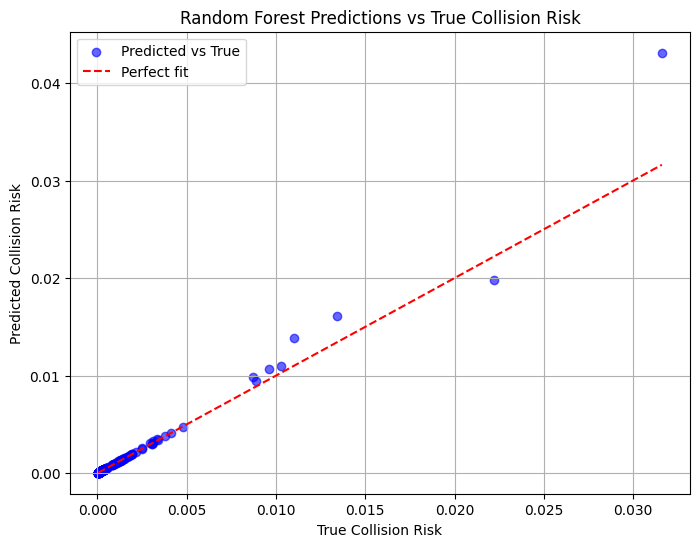

In [16]:
# Cell: Visualize predictions vs true values
import matplotlib.pyplot as plt

# Sample predictions and targets (replace with your actual arrays)
# preds = rf.predict(X_test)
# y_test already defined

plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6, color='blue', label='Predicted vs True')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
plt.xlabel("True Collision Risk")
plt.ylabel("Predicted Collision Risk")
plt.title("Random Forest Predictions vs True Collision Risk")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import pandas as pd

def save_gnn_metrics(y_true, y_pred, path="results/metrics/gnn_collision_metrics.csv"):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame({"y_true": y_true.tolist(), "y_pred": y_pred.tolist()})
    df.to_csv(path, index=False)